**Name:** Waseem Tunio  
**CMS ID:** 023-24-0199  
**Section:** F  
**GitHub Profile:** https://github.com/waseem-tunio  
**Kaggle Profile:** https://www.kaggle.com/waseemtuni0  
**Dataset:** Telco Customer Churn (cleaned)  
**Dataset Source:** Kaggle — Telco Customer Churn

# 1. Problem Definition

We are predicting **Churn** (Yes/No) for each customer using their account and service attributes. Correctly identifying customers likely to churn lets the business target them with retention offers before they leave, reducing revenue loss.

# 2. Dataset Verification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

df = pd.read_csv('clean_churn.csv')
df.shape

(7032, 20)

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 


In [3]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

The dataset has 7032 rows and 20 columns, all dtypes as expected, and no missing values. The target is imbalanced (about 73% No, 27% Yes), consistent with Lab 2's findings.

# 3. Feature/Target Preparation

In [4]:
y = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop(columns=['Churn'])
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [5]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
X['gender'] = X['gender'].map({'Female': 0, 'Male': 1})
for c in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    X[c] = X[c].map({'No': 0, 'Yes': 1})

multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']
X = pd.get_dummies(X, columns=multi_cols)
X.dtypes

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
MultipleLines_No                              bool
MultipleLines_No phone service                bool
MultipleLines_Yes                             bool
InternetService_DSL                           bool
InternetService_Fiber optic                   bool
InternetService_No                            bool
OnlineSecurity_No                             bool
OnlineSecurity_No internet service            bool
OnlineSecurity_Yes                            bool
OnlineBackup_No                               bool
OnlineBackup_No internet servic

Binary columns (gender, Partner, Dependents, PhoneService, PaperlessBilling) were manually mapped to 0/1 since they only have two categories and no order needs to be implied. Columns with 3+ unrelated categories (e.g. Contract, PaymentMethod) were one-hot encoded so the tree doesn't assume a false ordinal relationship between categories.

In [6]:
print(X.isnull().sum().sum())
print(X.dtypes.unique())

0
[dtype('int64') dtype('float64') dtype('bool')]


X is fully numeric (int/float/bool) with zero missing values.

# 4. Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

`stratify=y` keeps the same ~73/27 churn ratio in both the training and test sets. Since the target is imbalanced, a plain random split could by chance leave the test set with too few or too many churners, making evaluation misleading.

In [8]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5625, 40), (1407, 40), (5625,), (1407,))

# 5. Baseline Decision Tree

In [9]:
baseline = DecisionTreeClassifier(random_state=42)
baseline.fit(X_train, y_train)
baseline.get_depth()

24

In [10]:
pred_train_base = baseline.predict(X_train)
pred_test_base = baseline.predict(X_test)

The unrestricted tree grew to depth 24. This is not surprising — with no depth limit, a Decision Tree keeps splitting until leaves are pure (or nearly so), which almost always produces a very deep, highly specific tree on a dataset this size.

# 6. Model Evaluation

In [11]:
acc = accuracy_score(y_test, pred_test_base)
prec = precision_score(y_test, pred_test_base)
rec = recall_score(y_test, pred_test_base)
f1 = f1_score(y_test, pred_test_base)

pd.DataFrame({'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
              'Score': [acc, prec, rec, f1]})

,Metric,Score
0,Accuracy,0.726368
1,Precision,0.486352
2,Recall,0.524064
3,F1-score,0.504505


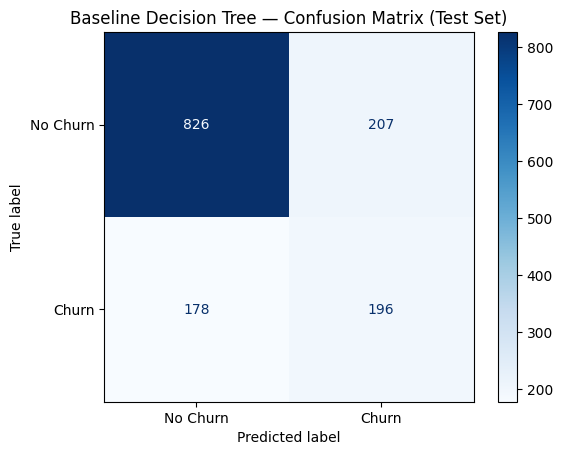

In [12]:
cm = confusion_matrix(y_test, pred_test_base)
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(cmap='Blues')
plt.title('Baseline Decision Tree — Confusion Matrix (Test Set)')
plt.show()

Out of 374 actual churners in the test set, the model correctly caught 196 and missed 178. It also produced 207 false alarms (predicted churn but customer stayed).

Given the class imbalance from Lab 2 accuracy is misleading. A model that always predicts 'No churn' would already score around 73%. Recall and F1-score for the churn class are more trustworthy in this case because missing a churner (false negative) is the more expensive mistake, for the business. Recall tells us how many of the churners the model actually identifies.

# 7. Overfitting Experiment

In [13]:
train_acc_base = accuracy_score(y_train, pred_train_base)
test_acc_base = accuracy_score(y_test, pred_test_base)
train_acc_base, test_acc_base

(0.9987555555555555, 0.7263681592039801)

The baseline tree scores nearly 100% on training data but only about 73% on the test set — a very large gap. This is a clear sign of overfitting: the unrestricted tree has memorized individual training rows (including noise) rather than learning patterns that generalize.

In [14]:
depths = [2, 3, 4, 5, 6, 8, 10, None]
records = []
for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, model.predict(X_train))
    te_acc = accuracy_score(y_test, model.predict(X_test))
    records.append({'max_depth': d, 'train_acc': tr_acc, 'test_acc': te_acc})

results_df = pd.DataFrame(records)
results_df

,max_depth,train_acc,test_acc
0,2.0,0.764622,0.751955
1,3.0,0.790756,0.778252
2,4.0,0.796267,0.779673
3,5.0,0.799111,0.789623
4,6.0,0.812622,0.790334
5,8.0,0.839289,0.769012
6,10.0,0.875022,0.754797
7,NaN,0.998756,0.726368


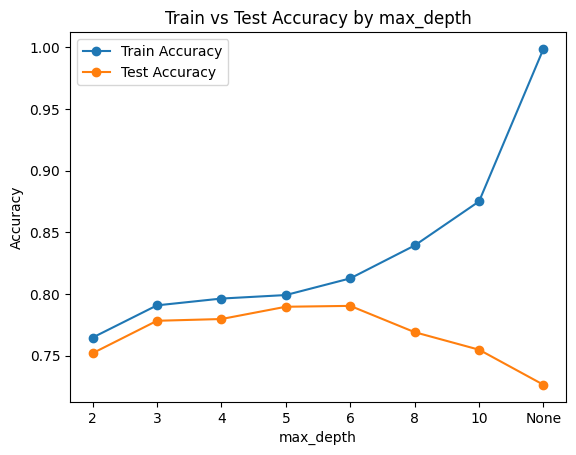

In [15]:
labels = [str(d) for d in depths]
plt.plot(labels, results_df['train_acc'], marker='o', label='Train Accuracy')
plt.plot(labels, results_df['test_acc'], marker='o', label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy by max_depth')
plt.legend()
plt.show()

Train accuracy keeps rising as depth increases. Test accuracy reaches its highest point around depth five to six and then falls. The two curves begin to pull apart after depth six to eight and, by depth ten and beyond the gap is huge. That widening gap is the signature of overfitting.

# 8. Model Comparison

In [16]:
chosen_depth = 6
chosen = DecisionTreeClassifier(max_depth=chosen_depth, random_state=42)
chosen.fit(X_train, y_train)
pred_chosen = chosen.predict(X_test)

Depth 6 is chosen because it gives the best (or near-best) test accuracy in the table above while keeping the train/test gap small, meaning the model is fitting real patterns rather than noise — not simply the depth with the highest training accuracy (that would be the unrestricted tree, which clearly overfits).

In [17]:
pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Baseline': [acc, prec, rec, f1],
    f'Depth={chosen_depth}': [accuracy_score(y_test, pred_chosen),
                               precision_score(y_test, pred_chosen),
                               recall_score(y_test, pred_chosen),
                               f1_score(y_test, pred_chosen)]
})

,Metric,Baseline,Depth=6
0,Accuracy,0.726368,0.790334
1,Precision,0.486352,0.616519
2,Recall,0.524064,0.558824
3,F1-score,0.504505,0.586255


The depth-6 model shows an improvement in precision, recall and F1 compared to the unconstrained baseline. Even though accuracy remains similar pruning the tree has made the depth-6 model better, at spotting churners.

In [18]:
entropy_model = DecisionTreeClassifier(max_depth=chosen_depth, criterion='entropy', random_state=42)
entropy_model.fit(X_train, y_train)
pred_entropy = entropy_model.predict(X_test)

pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Gini (depth=6)': [accuracy_score(y_test, pred_chosen),
                        precision_score(y_test, pred_chosen),
                        recall_score(y_test, pred_chosen),
                        f1_score(y_test, pred_chosen)],
    'Entropy (depth=6)': [accuracy_score(y_test, pred_entropy),
                           precision_score(y_test, pred_entropy),
                           recall_score(y_test, pred_entropy),
                           f1_score(y_test, pred_entropy)]
})

,Metric,Gini (depth=6),Entropy (depth=6)
0,Accuracy,0.790334,0.786780
1,Precision,0.616519,0.604520
2,Recall,0.558824,0.572193
3,F1-score,0.586255,0.587912


I notice that Gini and entropy produce identical results when the tree depth is six. Entropy has a lower precision but a slightly higher recall and F1. The splitting criterion does not make a practical difference; controlling depth is what matters most.

# 9. Feature Importance

In [19]:
importances = pd.Series(chosen.feature_importances_, index=X.columns).sort_values(ascending=False)
top_features = importances.head(8)
top_features

Contract_Month-to-month           0.480727
TotalCharges                      0.142822
InternetService_Fiber optic       0.139163
tenure                            0.065969
MonthlyCharges                    0.041605
TechSupport_No                    0.025589
PaymentMethod_Electronic check    0.018780
SeniorCitizen                     0.011561
dtype: float64

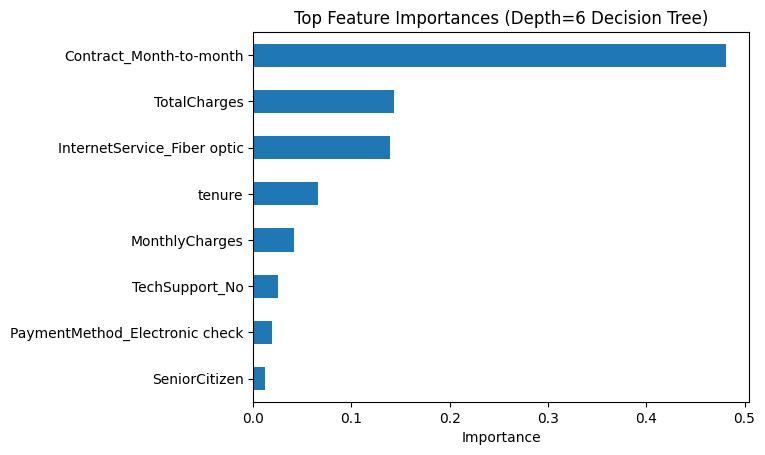

In [20]:
top_features.sort_values().plot(kind='barh')
plt.xlabel('Importance')
plt.title('Top Feature Importances (Depth=6 Decision Tree)')
plt.show()

# 10. Interpretation

The top features are **Contract_Month-to-month**, **TotalCharges**, **InternetService_Fiber optic**, **tenure**, and **MonthlyCharges**. This agrees with Lab 2's EDA: month-to-month contracts, fiber optic internet, low tenure, and high monthly charges were all associated with higher churn rates there too. Customers with no long-term commitment and higher costs are the most likely to leave, which matches what the tree learned as its strongest splits.

# 11. Conclusion

We built a Decision Tree classifier to predict Telco customer churn. The unrestricted baseline tree overfit badly (~99% train accuracy vs ~73% test accuracy), so we controlled complexity with `max_depth` and selected depth=6 as the best trade-off, giving ~79% test accuracy with much better precision/recall/F1 than the baseline. Its main limitations are moderate recall (it still misses a sizeable share of actual churners) and reliance on a single tree, which is less stable than an ensemble method.

With more time, next steps could include trying a different algorithm (e.g. Random Forest or Gradient Boosting), engineering additional features (e.g. tenure buckets, service-count totals), or explicitly handling the class imbalance (e.g. class weighting or SMOTE) to improve recall on the churn class.

### 23. ID3 from Scratch — Play Badminton Dataset

In [21]:
data = [
    {'Outlook':'Sunny','Temp':'Hot','Humidity':'High','Wind':'Weak','Play':'No'},
    {'Outlook':'Sunny','Temp':'Hot','Humidity':'High','Wind':'Strong','Play':'No'},
    {'Outlook':'Overcast','Temp':'Hot','Humidity':'High','Wind':'Weak','Play':'Yes'},
    {'Outlook':'Rain','Temp':'Mild','Humidity':'High','Wind':'Weak','Play':'Yes'},
    {'Outlook':'Rain','Temp':'Cool','Humidity':'Normal','Wind':'Weak','Play':'Yes'},
    {'Outlook':'Rain','Temp':'Cool','Humidity':'Normal','Wind':'Strong','Play':'No'},
    {'Outlook':'Overcast','Temp':'Cool','Humidity':'Normal','Wind':'Strong','Play':'Yes'},
    {'Outlook':'Sunny','Temp':'Mild','Humidity':'High','Wind':'Weak','Play':'No'},
    {'Outlook':'Sunny','Temp':'Cool','Humidity':'Normal','Wind':'Weak','Play':'Yes'},
    {'Outlook':'Rain','Temp':'Mild','Humidity':'Normal','Wind':'Weak','Play':'Yes'},
    {'Outlook':'Sunny','Temp':'Mild','Humidity':'Normal','Wind':'Strong','Play':'Yes'},
    {'Outlook':'Overcast','Temp':'Mild','Humidity':'High','Wind':'Strong','Play':'Yes'},
    {'Outlook':'Overcast','Temp':'Hot','Humidity':'Normal','Wind':'Weak','Play':'Yes'},
    {'Outlook':'Rain','Temp':'Mild','Humidity':'High','Wind':'Strong','Play':'No'},
]
badminton_df = pd.DataFrame(data)
badminton_df

,Outlook,Temp,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [22]:
def entropy(labels):
    counts = labels.value_counts()
    probs = counts / len(labels)
    return -sum(p * np.log2(p) for p in probs)

def info_gain(data, attribute, target='Play'):
    total_entropy = entropy(data[target])
    weighted_entropy = 0
    for value in data[attribute].unique():
        subset = data[data[attribute] == value]
        weighted_entropy += (len(subset) / len(data)) * entropy(subset[target])
    return total_entropy - weighted_entropy

def id3(data, attributes, target='Play', depth=0):
    labels = data[target]
    if len(labels.unique()) == 1:
        return labels.iloc[0]
    if not attributes:
        return labels.mode()[0]

    gains = {attr: info_gain(data, attr, target) for attr in attributes}
    print('  ' * depth + f"Gains at this split: {gains}")
    best_attr = max(gains, key=gains.get)
    print('  ' * depth + f"Splitting on: {best_attr}")

    tree = {best_attr: {}}
    remaining_attrs = [a for a in attributes if a != best_attr]
    for value in data[best_attr].unique():
        subset = data[data[best_attr] == value]
        if len(subset) == 0:
            tree[best_attr][value] = labels.mode()[0]
        else:
            tree[best_attr][value] = id3(subset, remaining_attrs, target, depth + 1)
    return tree

attributes = ['Outlook', 'Temp', 'Humidity', 'Wind']
tree = id3(badminton_df, attributes)
tree

Gains at this split: {'Outlook': np.float64(0.24674981977443933), 'Temp': np.float64(0.02922256565895487), 'Humidity': np.float64(0.15183550136234159), 'Wind': np.float64(0.04812703040826949)}
Splitting on: Outlook
  Gains at this split: {'Temp': np.float64(0.5709505944546686), 'Humidity': np.float64(0.9709505944546686), 'Wind': np.float64(0.01997309402197489)}
  Splitting on: Humidity
  Gains at this split: {'Temp': np.float64(0.01997309402197489), 'Humidity': np.float64(0.01997309402197489), 'Wind': np.float64(0.9709505944546686)}
  Splitting on: Wind


{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}},
  'Overcast': 'Yes',
  'Rain': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}}}